### Partie 1 – Exploration du corpus 

##### 1) Charger les données CSV 

In [3]:
import pandas as pd
df = pd.read_csv("../data/smart_reviews_raw.csv")
df

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr
...,...,...,...,...,...,...,...,...
1195,AV1196,2026-08-07,mobile,SmartPhone Y,La batterie se décharge beaucoup trop vite.,negatif,2,fr
1196,AV1197,2026-01-31,email,Écouteurs AirSound,"Très bonne expérience, simple et efficace. !!!",positif,5,fr
1197,AV1198,2026-04-02,web,SmartWatch Pro,Produit correct pour son prix. !!!,neutre,4,fr
1198,AV1199,2026-05-02,email,Tablette TabPlus,Excellent rapport qualité-prix. #avis,positif,5,fr


##### 2) Combien d'avis contient le dataset 

In [7]:
print("le nombre d'avis est : \n" , df.shape[0])

le nombre d'avis est : 
 1200


##### 3) Combien de colonnes possède-t-il

In [8]:
print("le nombre de colonne que possede le dataset est :\n", df.shape[1])

le nombre de colonne que possede le dataset est :
 8


##### 4) Quel est le type de chaque colonne 

In [11]:
print("le type de chaque colonne est :\n", df.dtypes)

le type de chaque colonne est :
 id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object


##### 5) Existe-t-il des valeurs manquantes ?

In [15]:
print("nombre de valeur manquante : \n", df.isna().sum())

nombre de valeur manquante : 
 id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64


Oui , il existe des valeurs manquantes au nombre de 5 au niveau e la colonne texte qui represente les avis.

##### 6) Identifier quelques types de texte en affichant par exemple : texte normal ; texte vide ; texte contenant une URL ; texte contenant une mention ; texte contenant un hashtag ; texte contenant des emojis ; texte avec beaucoup de ponctuation ; texte en majuscules ; texte avec répétition de caractères. 

In [17]:
import re
# 2. Définition de la fonction d'identification du type de texte
def identifier_type_texte(texte):
    # Gestion du texte vide ou ne contenant que des espaces
    if not str(texte).strip():
        return "texte vide"
        
    texte_str = str(texte)
    
    # Vérification des majuscules (au moins quelques lettres, et toutes en majuscules)
    if texte_str.isupper():
        return "texte en majuscules"
        
    # URL : commence par http, https ou www
    if re.search(r'https?://\S+|www\.\S+', texte_str):
        return "texte contenant une URL"
        
    # Mention : @ suivi de caractères alphanumériques
    if re.search(r'@\w+', texte_str):
        return "texte contenant une mention"
        
    # Hashtag : # suivi de caractères alphanumériques
    if re.search(r'#\w+', texte_str):
        return "texte contenant un hashtag"
        
    # Emojis : détection de la plage de caractères Unicode des emojis
    if re.search(r'[\U00010000-\U0010ffff]', texte_str):
        return "texte contenant des emojis"
        
    # Beaucoup de ponctuation 
    if re.search(r'[!?.,;:-]{3,}', texte_str):
        return "texte avec beaucoup de ponctuation"
        
    # Répétition de caractères 
    if re.search(r'(.)\1{2,}', texte_str):
        return "texte avec répétition de caractères"
        
    # Si aucun critère spécifique n'est rempli
    return "texte normal"

# 3. Application de la fonction sur le DataFrame
df['type_de_texte'] = df['texte'].apply(identifier_type_texte)

# 4. Affichage du résultat
df[['texte', 'type_de_texte']]

,texte,type_de_texte
0,"Très bonne expérience, simple et efficace.",texte normal
1,Très satisfait de mon achat 👍 #avis,texte contenant un hashtag
2,"Produit parfait, rien à signaler.",texte normal
3,"Produit excellent, je suis très satisfait. !!!",texte avec beaucoup de ponctuation
4,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,texte en majuscules
...,...,...
1195,La batterie se décharge beaucoup trop vite.,texte normal
1196,"Très bonne expérience, simple et efficace. !!!",texte avec beaucoup de ponctuation
1197,Produit correct pour son prix. !!!,texte avec beaucoup de ponctuation
1198,Excellent rapport qualité-prix. #avis,texte contenant un hashtag


##### 7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur » pour déterminer : longueur minimale ; longueur maximale ; longueur moyenne ; médiane et quartiles. 

In [26]:
# 1. Création de la colonne « longueur » (nombre de caractères)
df['longueur'] = df['texte'].str.len()

# 2. Calcul et affichage des statistiques descriptives
statistiques = df['longueur'].describe()

print("--- Statistiques de longueur ---")
print(f"Longueur minimale : {statistiques['min']}")
print(f"Longueur maximale : {statistiques['max']}")
print(f"Longueur moyenne  : {statistiques['mean']:.2f}")
print(f"Médiane (50%)     : {statistiques['50%']}")
print(f"Premier quartile (25%)  : {statistiques['25%']}")
print(f"Troisième quartile (75%): {statistiques['75%']}")


--- Statistiques de longueur ---
Longueur minimale : 2.0
Longueur maximale : 636.0
Longueur moyenne  : 49.17
Médiane (50%)     : 48.0
Premier quartile (25%)  : 37.0
Troisième quartile (75%): 56.0


##### 8) Visualiser la distribution de la longueur des avis puis répondre aux questions 

C:\Users\dell\AppData\Local\Temp\ipykernel_9084\1371651433.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


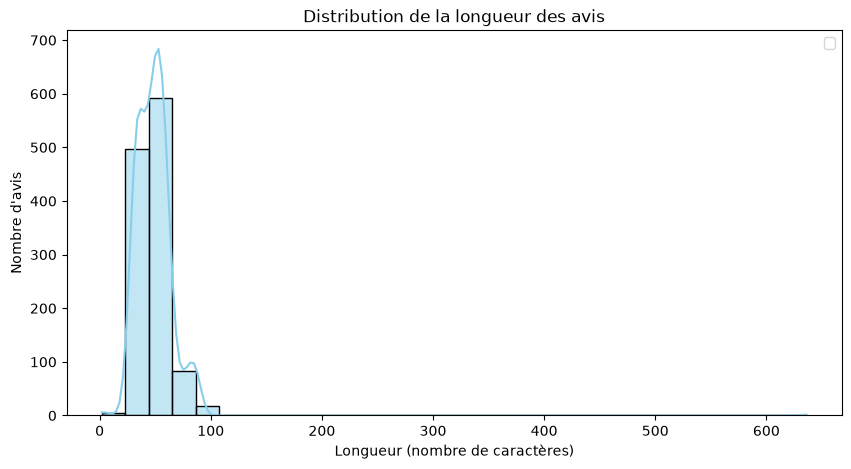

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Graphique : Histogramme avec courbe de densité
sns.histplot(df['longueur'], kde=True, color='skyblue', bins=30)
plt.title("Distribution de la longueur des avis")
plt.xlabel("Longueur (nombre de caractères)")
plt.ylabel("Nombre d'avis")


plt.legend()
plt.show()

##### a) Existe-t-il des textes anormalement longs ?

***Oui, le graphique met clairement en évidence la présence d'une valeur aberrante (outlier) à l'extrême droite. Alors que la quasi-totalité des avis ont une longueur standard concentrée entre 20 et 100 caractères, il existe au moins un texte anormalement long qui atteint environ 640 caractères.***

##### b) Existe-t-il beaucoup de textes très courts ? 

***Non, il y a très peu de textes excessivement courts. Le graphique montre que le nombre d'avis est presque nul en dessous de 20 caractères. La grande majorité des données commence à se densifier fortement à partir de 30 caractères, ce qui indique que les utilisateurs écrivent presque tous des messages d'une longueur minimale standard.***

##### 9) Détecter les textes vides

In [38]:
# on fait d'abord le filtrage pour ensuite afficher les textes vides
masque_vide = (df['texte'].str.strip() == '')

# Affiche des lignes correspondantes
df_vides = df[masque_vide]
df_vides

,id_avis,date,source,produit,texte,sentiment,note,langue,type_de_texte,longueur
951,AV0952,2026-06-11,web,Ordinateur NovaBook,,positif,4,fr,texte vide,3.0


##### 10) Détecter les doublons sur le texte 

In [48]:
doublons = df['texte'].duplicated()
df_doublons= df[doublons]
df_doublons

,id_avis,date,source,produit,texte,sentiment,note,langue,type_de_texte,longueur
11,AV0012,2026-06-25,email,SmartPhone X,"Produit parfait, rien à signaler.",positif,5,fr,texte normal,37.0
17,AV0018,2026-04-09,sav,Tablette TabPlus,SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...,positif,5,fr,texte en majuscules,52.0
27,AV0028,2026-04-26,web,SmartPhone Y,Excellent rapport qualité-prix.,positif,5,fr,texte normal,31.0
37,AV0038,2026-04-08,web,Écouteurs AirSound,"Produit excellent, je suis très satisfait. !!!",positif,5,fr,texte avec beaucoup de ponctuation,46.0
41,AV0042,2026-01-21,mobile,SmartPhone X,"Produit excellent, je suis trèèès satisfait.",positif,5,fr,texte avec répétition de caractères,44.0
...,...,...,...,...,...,...,...,...,...,...
1195,AV1196,2026-08-07,mobile,SmartPhone Y,La batterie se décharge beaucoup trop vite.,negatif,2,fr,texte normal,43.0
1196,AV1197,2026-01-31,email,Écouteurs AirSound,"Très bonne expérience, simple et efficace. !!!",positif,5,fr,texte avec beaucoup de ponctuation,46.0
1197,AV1198,2026-04-02,web,SmartWatch Pro,Produit correct pour son prix. !!!,neutre,4,fr,texte avec beaucoup de ponctuation,34.0
1198,AV1199,2026-05-02,email,Tablette TabPlus,Excellent rapport qualité-prix. #avis,positif,5,fr,texte contenant un hashtag,37.0


##### 11) Les classes sont-elles équilibrées ? 

In [ ]:
# On Compte le nombre de lignes par classe(positif , neutre ou negatif)
print(df['sentiment'].value_counts())

# Puis on calcule les proportions en pourcentage
print(df['sentiment'].value_counts(normalize=True) * 100)


sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64
sentiment
positif    64.666667
neutre     20.500000
negatif    14.833333
Name: proportion, dtype: float64


***Non, les classes ne sont pas équilibrées. La classe 'positif' est largement majoritaire et représente à elle seule près des deux tiers des données (64,67 %), soit 776 avis.En comparaison, les classes 'neutre' (20,50 %) et 'négatif' (14,83 %) sont fortement minoritaires. Il y a un déséquilibre marqué.***

##### 12) Quelle est la classe majoritaire ? 

***La classe majoritaire est la classe 'Positif' avec un effectif de 776 et un pourcentage de 64.666667***

##### 13) Quelles métriques de classification à envisager d’utiliser ? 

Le jeu de données étant fortement déséquilibré, la métrique standard de l'Exactitude (Accuracy) est à proscrire car elle masquerait les mauvaises performances sur les classes minoritaires. Il faut envisager d'utiliser :

--Le F1-Score (notamment le Macro F1-score) comme indicateur global, car il traite équitablement chaque classe sans favoriser la classe majoritaire.

--Le Rappel (Recall) spécifiquement sur la classe 'négatif', afin de s'assurer que l'on capture un maximum de clients mécontents.

--La Matrice de Confusion pour analyser en détail les erreurs de prédiction entre les trois sentiments.